# 07. Two-Stage Recommendation: ALS Retrieval + LGBM Ranking

프로덕션 추천 시스템의 핵심 패턴인 **Two-Stage** 구조를 구현합니다.

| Stage | 모델 | 역할 |
|---|---|---|
| **Retrieval** | ALS (행렬분해) | 빠르게 후보 ~200개 추출 |
| **Ranking** | LightGBM | 피처 기반으로 후보를 re-rank |

참고: [levit/alwayz-recommendation](../../levit 레퍼런스) — W2V retrieval + LGBM ranking 프로덕션 구현

## 1. 데이터 준비 & Train/Test Split

In [1]:
%%time
import os
import pickle
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import sparse

from gharchive.loader import load_period
from ghrec.recommend import popularity_scores

OUTPUT_DIR = Path("../../data/daily_agg")
MODEL_DIR = Path("../../data/models")
MODEL_DIR.mkdir(exist_ok=True)

# 최신 데이터 활용: 5주 train + 1주 test
TRAIN_START, TRAIN_END = date(2026, 3, 1), date(2026, 3, 28)
TEST_START, TEST_END   = date(2026, 3, 29), date(2026, 4, 3)

WEIGHTS = {
    "WatchEvent": 1.0,
    "ForkEvent": 2.0,
    "IssuesEvent": 0.5,
    "PullRequestEvent": 3.0,
    "IssueCommentEvent": 0.3,
    "PushEvent": 0.2,
}

train_df = load_period(OUTPUT_DIR, TRAIN_START, TRAIN_END)
test_df  = load_period(OUTPUT_DIR, TEST_START, TEST_END)

print(f"Train: {len(train_df):,} rows  ({TRAIN_START} ~ {TRAIN_END})")
print(f"Test:  {len(test_df):,} rows  ({TEST_START} ~ {TEST_END})")

Train: 39,013,569 rows  (2026-03-01 ~ 2026-03-28)
Test:  8,424,892 rows  (2026-03-29 ~ 2026-04-03)
CPU times: user 3.26 s, sys: 808 ms, total: 4.07 s
Wall time: 2.91 s


In [2]:
# 유저 샘플링 — 메모리 절약
SAMPLE_RATIO = 0.30
rng = np.random.default_rng(42)

all_users = set(train_df["actor_id"].unique()) | set(test_df["actor_id"].unique())
sampled_users = set(rng.choice(list(all_users), size=int(len(all_users) * SAMPLE_RATIO), replace=False))

train_df = train_df[train_df["actor_id"].isin(sampled_users)]
test_df  = test_df[test_df["actor_id"].isin(sampled_users)]

print(f"Sampled {SAMPLE_RATIO:.0%} users: {len(sampled_users):,}")
print(f"Train: {len(train_df):,} rows")
print(f"Test:  {len(test_df):,} rows")

Sampled 30% users: 2,136,388
Train: 14,520,469 rows
Test:  3,113,857 rows


In [3]:
def build_feedback(df, weights):
    """이벤트 가중치 적용 → (actor_id, repo_id, score) 집계."""
    df = df.copy()
    df["score"] = df["type"].map(weights).fillna(0) * df["cnt"]
    fb = df.groupby(["actor_id", "repo_id"])["score"].sum().reset_index()
    return fb[fb["score"] > 0]

train_fb = build_feedback(train_df, WEIGHTS)
test_fb  = build_feedback(test_df, WEIGHTS)

# 평가 대상: Train ∩ Test 유저 (10,000명 샘플 — 속도)
eval_users_all = sorted(set(train_fb["actor_id"]) & set(test_fb["actor_id"]))
EVAL_SAMPLE = 10_000
eval_users = list(rng.choice(eval_users_all, size=min(EVAL_SAMPLE, len(eval_users_all)), replace=False))
test_gt = test_fb.groupby("actor_id")["repo_id"].apply(set).to_dict()

print(f"Train feedback: {len(train_fb):,} (유저 {train_fb['actor_id'].nunique():,}, 레포 {train_fb['repo_id'].nunique():,})")
print(f"Test feedback:  {len(test_fb):,}")
print(f"평가 유저 (전체): {len(eval_users_all):,} → 샘플: {len(eval_users):,}")

Train feedback: 3,922,402 (유저 1,653,976, 레포 3,212,631)
Test feedback:  1,318,118
평가 유저 (전체): 436,871 → 샘플: 10,000


## 2. Stage 1: ALS Retrieval

Sparse matrix 구축 → ALS 학습 → 유저별 후보 200개 추출

In [4]:
# Index 매핑
all_user_ids = train_fb["actor_id"].unique()
all_item_ids = train_fb["repo_id"].unique()

user2idx = {uid: i for i, uid in enumerate(all_user_ids)}
item2idx = {iid: i for i, iid in enumerate(all_item_ids)}
idx2item = {i: iid for iid, i in item2idx.items()}

row = train_fb["actor_id"].map(user2idx).values
col = train_fb["repo_id"].map(item2idx).values
data = train_fb["score"].values.astype(np.float32)

train_sparse = sparse.csr_matrix(
    (data, (row, col)),
    shape=(len(all_user_ids), len(all_item_ids)),
)
print(f"Sparse matrix: {train_sparse.shape[0]:,} × {train_sparse.shape[1]:,}")
print(f"Non-zero: {train_sparse.nnz:,}")

Sparse matrix: 1,653,976 × 3,212,631
Non-zero: 3,922,402


In [5]:
%%time
from implicit.als import AlternatingLeastSquares

ALS_PATH = MODEL_DIR / "als_twostage.pkl"

if ALS_PATH.exists():
    model = pickle.loads(ALS_PATH.read_bytes())
    print(f"ALS 로드: {ALS_PATH}")
else:
    model = AlternatingLeastSquares(
        factors=64,
        regularization=0.01,
        iterations=15,
        random_state=42,
    )
    model.fit(train_sparse)
    ALS_PATH.write_bytes(pickle.dumps(model))
    print(f"ALS 학습 완료 — factors={model.factors}, saved to {ALS_PATH}")

/Users/kakao/bda-2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ALS 로드: ../../data/models/als_twostage.pkl
CPU times: user 148 ms, sys: 396 ms, total: 544 ms
Wall time: 639 ms


In [6]:
%%time
# 후보 200개 retrieval (배치 청크)
CANDIDATE_K = 200
CHUNK_SIZE = 2000

retrieval_results = {}
for start in range(0, len(eval_users), CHUNK_SIZE):
    chunk_users = eval_users[start:start + CHUNK_SIZE]
    chunk_idxs = np.array([user2idx[uid] for uid in chunk_users])
    
    item_ids_batch, scores_batch = model.recommend(
        chunk_idxs,
        train_sparse[chunk_idxs],
        N=CANDIDATE_K,
        filter_already_liked_items=True,
    )
    
    for i, uid in enumerate(chunk_users):
        retrieval_results[uid] = [
            (idx2item[j], float(scores_batch[i][rank]))
            for rank, j in enumerate(item_ids_batch[i])
        ]
    print(f"  {min(start + CHUNK_SIZE, len(eval_users)):,}/{len(eval_users):,} users done")

print(f"\nRetrieval 완료: {len(retrieval_results):,} 유저 × {CANDIDATE_K} 후보")
print(f"예시 (첫 유저 top-5):")
for repo_id, score in list(retrieval_results.values())[0][:5]:
    print(f"  repo={repo_id}, als_score={score:.4f}")

  2,000/10,000 users done


  4,000/10,000 users done


  6,000/10,000 users done


  8,000/10,000 users done


  10,000/10,000 users done

Retrieval 완료: 10,000 유저 × 200 후보
예시 (첫 유저 top-5):
  repo=320636477, als_score=0.0000
  repo=769448967, als_score=0.0000
  repo=1154499097, als_score=0.0000
  repo=1146968755, als_score=0.0000
  repo=285902689, als_score=0.0000
CPU times: user 1min 51s, sys: 32.5 s, total: 2min 23s
Wall time: 50.6 s


## 3. 피처 엔지니어링

LGBM ranker에 들어갈 피처를 구성합니다.

levit 참고 구조: `[user_embedding || item_embedding || metadata_features]`

우리 피처:
- **ALS score**: retrieval 단계의 점수 (collaborative signal)
- **ALS embedding similarity**: user vector · item vector cosine
- **Item popularity**: train 기간 가중 점수
- **Repo metadata**: stargazers, forks, language (SQLite 캐시)
- **User activity**: train 기간 총 이벤트 수, 고유 repo 수

In [7]:
# Item popularity scores (train 기간)
pop_scores = popularity_scores(train_df, WEIGHTS)
pop_dict = pop_scores.to_dict()

# User activity features
user_activity = train_fb.groupby("actor_id").agg(
    user_total_score=("score", "sum"),
    user_unique_repos=("repo_id", "nunique"),
).to_dict(orient="index")

print(f"Popularity scores: {len(pop_dict):,} repos")
print(f"User activity: {len(user_activity):,} users")

Popularity scores: 3,884,804 repos
User activity: 1,653,976 users


In [8]:
# Repo metadata from SQLite cache
import sqlite3

DB_PATH = Path("../../data/repo_metadata.db")

if DB_PATH.exists():
    conn = sqlite3.connect(str(DB_PATH))
    meta_df = pd.read_sql_query("SELECT repo_id, language, stargazers, forks FROM repo_metadata WHERE http_status = 200", conn)
    meta_dict = meta_df.set_index("repo_id").to_dict(orient="index")
    conn.close()
    print(f"Metadata loaded: {len(meta_dict):,} repos")
else:
    meta_dict = {}
    print("No metadata DB found — metadata features will be 0")

# Language → numeric encoding (None/NaN 제외)
all_languages = sorted(
    lang for lang in set(m.get("language") for m in meta_dict.values())
    if isinstance(lang, str)
)
lang2idx = {lang: i + 1 for i, lang in enumerate(all_languages)}  # 0 = unknown
print(f"Languages: {len(lang2idx)} unique")

Metadata loaded: 91 repos
Languages: 20 unique


In [9]:
from sklearn.metrics.pairwise import cosine_similarity

# ALS embeddings
user_factors = model.user_factors  # (n_users, factors)
item_factors = model.item_factors  # (n_items, factors)

def build_ranking_features(uid, candidates):
    """유저-후보 쌍에 대한 피처 행렬 생성.
    
    candidates: [(repo_id, als_score), ...]
    returns: np.ndarray (n_candidates, n_features), list[repo_id]
    """
    uidx = user2idx[uid]
    u_vec = user_factors[uidx].reshape(1, -1)  # (1, 64)
    u_act = user_activity.get(uid, {"user_total_score": 0, "user_unique_repos": 0})
    
    rows = []
    repo_ids = []
    for repo_id, als_score in candidates:
        iidx = item2idx.get(repo_id)
        if iidx is None:
            continue
        
        i_vec = item_factors[iidx].reshape(1, -1)
        cos_sim = float(cosine_similarity(u_vec, i_vec)[0, 0])
        
        meta = meta_dict.get(repo_id, {})
        
        row = [
            als_score,                                    # ALS retrieval score
            cos_sim,                                      # cosine similarity
            np.log1p(pop_dict.get(repo_id, 0)),           # log popularity
            np.log1p(meta.get("stargazers", 0) or 0),     # log stars
            np.log1p(meta.get("forks", 0) or 0),          # log forks
            lang2idx.get(meta.get("language"), 0),         # language code
            u_act["user_total_score"],                     # user total activity
            u_act["user_unique_repos"],                    # user diversity
        ]
        rows.append(row)
        repo_ids.append(repo_id)
    
    return np.array(rows, dtype=np.float32), repo_ids

FEATURE_NAMES = [
    "als_score", "cos_sim", "log_popularity",
    "log_stars", "log_forks", "language",
    "user_total_score", "user_unique_repos",
]

# 테스트
sample_uid = eval_users[0]
X_sample, rids_sample = build_ranking_features(sample_uid, retrieval_results[sample_uid])
print(f"피처 shape: {X_sample.shape}")
print(f"피처 이름: {FEATURE_NAMES}")
print(f"첫 후보: {dict(zip(FEATURE_NAMES, X_sample[0]))}")

피처 shape: (200, 8)
피처 이름: ['als_score', 'cos_sim', 'log_popularity', 'log_stars', 'log_forks', 'language', 'user_total_score', 'user_unique_repos']
첫 후보: {'als_score': np.float32(4.3899032e-05), 'cos_sim': np.float32(0.28697863), 'log_popularity': np.float32(8.11582), 'log_stars': np.float32(9.177817), 'log_forks': np.float32(7.5427437), 'language': np.float32(7.0), 'user_total_score': np.float32(1.0), 'user_unique_repos': np.float32(2.0)}


## 4. LGBM 학습 데이터 생성

Label: 후보 repo가 test 기간에 실제 상호작용이 있었으면 1, 아니면 0

In [10]:
%%time
from tqdm import tqdm

# Train/val split: 평가 유저의 80%로 LGBM 학습, 20%로 검증
rng = np.random.default_rng(42)
shuffled = rng.permutation(eval_users)
split_idx = int(len(shuffled) * 0.8)
lgbm_train_users = shuffled[:split_idx]
lgbm_val_users = shuffled[split_idx:]

def build_dataset(user_list, retrieval_results, test_gt):
    """유저 리스트에 대해 (X, y) 구성."""
    all_X, all_y, all_qids = [], [], []
    for uid in tqdm(user_list, desc="Building features"):
        candidates = retrieval_results.get(uid, [])
        if not candidates:
            continue
        X, repo_ids = build_ranking_features(uid, candidates)
        if len(repo_ids) == 0:
            continue
        gt = test_gt.get(uid, set())
        y = np.array([1 if rid in gt else 0 for rid in repo_ids], dtype=np.float32)
        all_X.append(X)
        all_y.append(y)
        all_qids.append(len(repo_ids))  # group size for LambdaRank
    return np.vstack(all_X), np.concatenate(all_y), all_qids

X_train, y_train, q_train = build_dataset(lgbm_train_users, retrieval_results, test_gt)
X_val, y_val, q_val = build_dataset(lgbm_val_users, retrieval_results, test_gt)

print(f"\nTrain: {X_train.shape}, positive ratio: {y_train.mean():.4f}")
print(f"Val:   {X_val.shape}, positive ratio: {y_val.mean():.4f}")
print(f"Train groups: {len(q_train)}, Val groups: {len(q_val)}")

Building features:   0%|          | 0/8000 [00:00<?, ?it/s]

Building features:   0%|          | 2/8000 [00:00<10:42, 12.44it/s]

Building features:   0%|          | 4/8000 [00:00<08:46, 15.20it/s]

Building features:   0%|          | 6/8000 [00:00<07:58, 16.70it/s]

Building features:   0%|          | 9/8000 [00:00<06:59, 19.04it/s]

...

Building features: 100%|█████████▉| 1993/2000 [01:06<00:00, 29.87it/s]

Building features: 100%|█████████▉| 1996/2000 [01:06<00:00, 29.80it/s]

Building features: 100%|█████████▉| 1999/2000 [01:06<00:00, 29.73it/s]

Building features: 100%|██████████| 2000/2000 [01:06<00:00, 30.06it/s]


Train: (1600000, 8), positive ratio: 0.0001
Val:   (400000, 8), positive ratio: 0.0001
Train groups: 8000, Val groups: 2000
CPU times: user 5min 26s, sys: 18.2 s, total: 5min 45s
Wall time: 5min 34s


## 5. Stage 2: LightGBM Ranking

LambdaRank objective로 학습 — 순서 최적화에 특화된 학습 방식입니다.

In [11]:
%%time
import lightgbm as lgb

train_set = lgb.Dataset(X_train, label=y_train, group=q_train, feature_name=FEATURE_NAMES)
val_set = lgb.Dataset(X_val, label=y_val, group=q_val, feature_name=FEATURE_NAMES, reference=train_set)

params = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "eval_at": [10, 50],
    "num_leaves": 31,
    "learning_rate": 0.05,
    "min_child_samples": 20,
    "feature_fraction": 0.8,
    "verbose": -1,
}

ranker = lgb.train(
    params,
    train_set,
    num_boost_round=300,
    valid_sets=[val_set],
    callbacks=[
        lgb.log_evaluation(50),
        lgb.early_stopping(30),
    ],
)

print(f"\nBest iteration: {ranker.best_iteration}")

Training until validation scores don't improve for 30 rounds


Early stopping, best iteration is:
[7]	valid_0's ndcg@10: 0.993095	valid_0's ndcg@50: 0.993662

Best iteration: 7
CPU times: user 11.9 s, sys: 765 ms, total: 12.7 s
Wall time: 3.12 s


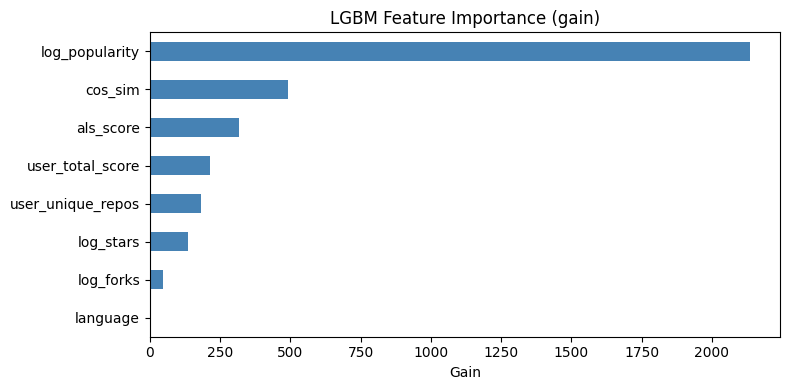

language                0.000000
log_forks              45.117790
log_stars             137.057461
user_unique_repos     183.402221
user_total_score      215.055119
als_score             316.410242
cos_sim               491.061899
log_popularity       2135.547953
dtype: float64


In [12]:
# Feature importance
import matplotlib.pyplot as plt

importance = pd.Series(
    ranker.feature_importance(importance_type="gain"),
    index=FEATURE_NAMES,
).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
importance.plot.barh(ax=ax, color="steelblue")
ax.set_title("LGBM Feature Importance (gain)")
ax.set_xlabel("Gain")
plt.tight_layout()
plt.show()

print(importance)

## 6. Two-Stage 추천 & 평가

Stage 1 (ALS) → Stage 2 (LGBM re-rank) → 최종 Top-K

In [13]:
%%time
import math

K_VALUES = [10, 50, 100]
MAX_K = max(K_VALUES)

def rerank_user(uid, candidates, ranker):
    """LGBM으로 후보를 re-rank하여 repo_id 리스트 반환."""
    X, repo_ids = build_ranking_features(uid, candidates)
    if len(repo_ids) == 0:
        return [rid for rid, _ in candidates[:MAX_K]]
    scores = ranker.predict(X)
    ranked_idx = np.argsort(-scores)
    return [repo_ids[i] for i in ranked_idx]

# ALS only (Stage 1 순서 그대로)
als_recs = {uid: [rid for rid, _ in cands[:MAX_K]] for uid, cands in retrieval_results.items()}

# Two-Stage (ALS → LGBM re-rank)
twostage_recs = {}
for uid in tqdm(eval_users, desc="Re-ranking"):
    twostage_recs[uid] = rerank_user(uid, retrieval_results[uid], ranker)

# Popularity baseline
train_scores = popularity_scores(train_df, WEIGHTS)
pop_candidates = train_scores.head(MAX_K + 500).index.tolist()
train_seen = train_fb.groupby("actor_id")["repo_id"].apply(set).to_dict()
pop_recs = {}
for uid in eval_users:
    seen = train_seen.get(uid, set())
    pop_recs[uid] = [r for r in pop_candidates if r not in seen][:MAX_K]

print(f"평가 유저: {len(eval_users):,}")

Re-ranking:   0%|          | 0/10000 [00:00<?, ?it/s]

Re-ranking:   0%|          | 3/10000 [00:00<05:41, 29.26it/s]

Re-ranking:   0%|          | 6/10000 [00:00<05:39, 29.45it/s]

Re-ranking:   0%|          | 9/10000 [00:00<05:37, 29.62it/s]

Re-ranking:   0%|          | 12/10000 [00:00<05:36, 29.69it/s]

...

Re-ranking: 100%|█████████▉| 9993/10000 [05:34<00:00, 29.58it/s]

Re-ranking: 100%|█████████▉| 9997/10000 [05:34<00:00, 29.87it/s]

Re-ranking: 100%|██████████| 10000/10000 [05:34<00:00, 29.89it/s]

Re-ranking: 100%|██████████| 10000/10000 [05:34<00:00, 29.92it/s]

평가 유저: 10,000
CPU times: user 6min 5s, sys: 17.3 s, total: 6min 23s
Wall time: 6min 8s


In [14]:
def precision_recall_ndcg(recommended, relevant, k):
    rec_set = set(recommended[:k])
    hits = rec_set & relevant
    precision = len(hits) / k if k > 0 else 0
    recall = len(hits) / len(relevant) if relevant else 0
    dcg = sum(1.0 / math.log2(i + 2) for i, rid in enumerate(recommended[:k]) if rid in relevant)
    idcg = sum(1.0 / math.log2(i + 2) for i in range(min(len(relevant), k)))
    ndcg = dcg / idcg if idcg > 0 else 0
    return precision, recall, ndcg

# 모델별 평가
results = {model_name: {k: {"precision": [], "recall": [], "ndcg": []} for k in K_VALUES}
           for model_name in ["Popularity", "ALS", "Two-Stage"]}

for uid in eval_users:
    gt = test_gt.get(uid, set())
    if not gt:
        continue
    for model_name, recs_dict in [("Popularity", pop_recs), ("ALS", als_recs), ("Two-Stage", twostage_recs)]:
        recs = recs_dict.get(uid, [])
        for k in K_VALUES:
            p, r, n = precision_recall_ndcg(recs, gt, k)
            results[model_name][k]["precision"].append(p)
            results[model_name][k]["recall"].append(r)
            results[model_name][k]["ndcg"].append(n)

# 결과 테이블
print(f"{'Model':<14} {'K':>3}  {'Precision':>10} {'Recall':>10} {'NDCG':>10}")
print("-" * 52)
for model_name in ["Popularity", "ALS", "Two-Stage"]:
    for k in K_VALUES:
        p = np.mean(results[model_name][k]["precision"])
        r = np.mean(results[model_name][k]["recall"])
        n = np.mean(results[model_name][k]["ndcg"])
        print(f"{model_name:<14} {k:>3}  {p:>10.5f} {r:>10.5f} {n:>10.5f}")

Model            K   Precision     Recall       NDCG
----------------------------------------------------
Popularity      10     0.00010    0.00053    0.00020
Popularity      50     0.00008    0.00214    0.00057
Popularity     100     0.00008    0.00494    0.00107
ALS             10     0.00043    0.00214    0.00107
ALS             50     0.00018    0.00490    0.00175
ALS            100     0.00011    0.00582    0.00193
Two-Stage       10     0.00101    0.00543    0.00461
Two-Stage       50     0.00022    0.00592    0.00471
Two-Stage      100     0.00011    0.00594    0.00472


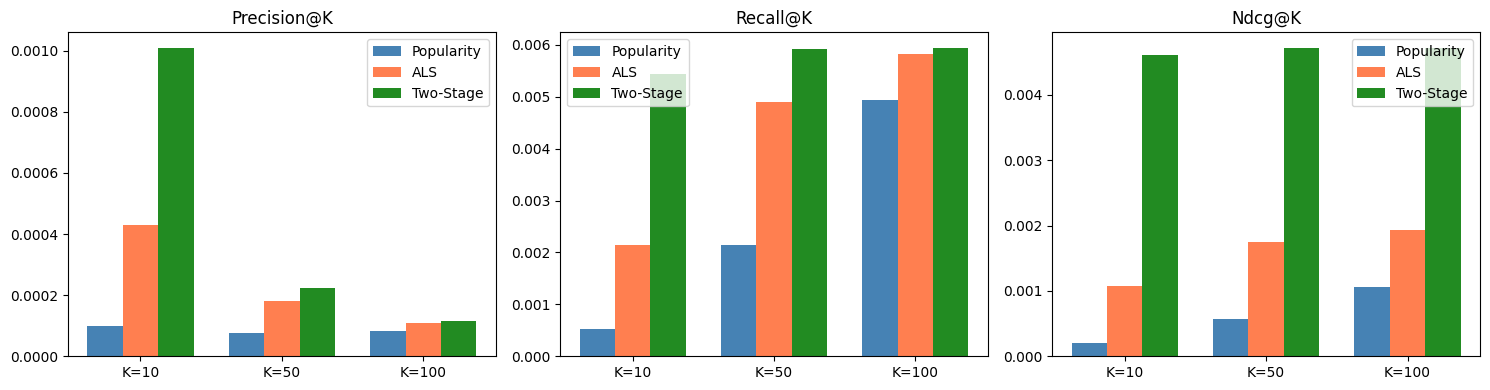

In [15]:
# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {"Popularity": "steelblue", "ALS": "coral", "Two-Stage": "forestgreen"}
bar_width = 0.25

for ax, metric in zip(axes, ["precision", "recall", "ndcg"]):
    x = np.arange(len(K_VALUES))
    for i, model_name in enumerate(["Popularity", "ALS", "Two-Stage"]):
        vals = [np.mean(results[model_name][k][metric]) for k in K_VALUES]
        ax.bar(x + i * bar_width, vals, bar_width, label=model_name, color=colors[model_name])
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels([f"K={k}" for k in K_VALUES])
    ax.set_title(f"{metric.title()}@K")
    ax.legend()

plt.tight_layout()
plt.show()

## 7. 추천 다양성 비교

In [16]:
k = 50
for model_name, recs_dict in [("Popularity", pop_recs), ("ALS", als_recs), ("Two-Stage", twostage_recs)]:
    unique_items = set()
    for uid in eval_users:
        unique_items.update(recs_dict.get(uid, [])[:k])
    print(f"{model_name:<14} K={k}: {len(unique_items):,} unique items recommended")

Popularity     K=50: 52 unique items recommended
ALS            K=50: 4,607 unique items recommended
Two-Stage      K=50: 5,934 unique items recommended


## 8. 모델 저장

Streamlit 대시보드에서 사용할 아티팩트 저장

In [ ]:
# LGBM ranker 저장
RANKER_PATH = MODEL_DIR / "lgbm_ranker.txt"
ranker.save_model(str(RANKER_PATH))
print(f"LGBM ranker saved: {RANKER_PATH}")

# ALS 모델은 이미 저장됨
print(f"ALS model: {ALS_PATH}")

# Index 매핑 저장
MAPPING_PATH = MODEL_DIR / "index_mappings.pkl"
pickle.dump({
    "user2idx": user2idx,
    "item2idx": item2idx,
    "idx2item": idx2item,
    "lang2idx": lang2idx,
    "pop_dict": pop_dict,
    "user_activity": user_activity,
    "feature_names": FEATURE_NAMES,
}, open(MAPPING_PATH, "wb"))
print(f"Mappings saved: {MAPPING_PATH}")

# Repo name 매핑 (BigQuery — 3월 전체 wildcard)
from gharchive.client import create_client

KEY_PATH = os.environ.get("GCP_KEY_PATH", str(Path("../../gcp-key.json")))
bq_client = create_client(KEY_PATH)

query = """
SELECT DISTINCT repo.id AS repo_id, repo.name AS repo_name
FROM `githubarchive.day.202603*`
"""
print("Querying repo names (3월 전체)...")
name_df = bq_client.query(query).to_dataframe()
name_map = dict(zip(name_df["repo_id"], name_df["repo_name"]))

NAME_MAP_PATH = MODEL_DIR / "repo_name_map.pkl"
pickle.dump(name_map, open(NAME_MAP_PATH, "wb"))
print(f"Repo names saved: {len(name_map):,} repos → {NAME_MAP_PATH}")

## 9. 정리

### Two-Stage 구조 요약

```
유저 → [ALS Retrieval] → 후보 200개 → [LGBM Ranking] → Top-K 추천
              │                              │
        collaborative signal           + metadata features
        (행렬분해 임베딩)              (stars, forks, language,
                                       popularity, user activity)
```

### levit 프로덕션과의 비교

| | levit (프로덕션) | 우리 (교육용) |
|---|---|---|
| Retrieval | W2V + KNN + 규칙 | ALS |
| Ranking | LGBM + 비즈니스 룰 | LGBM (LambdaRank) |
| 피처 | W2V 임베딩 + 유저 데모 | ALS score + 메타데이터 |
| Post-process | 카테고리 다양성, 필터링 | 없음 |
| 서빙 | Flask + Redis + Triton | Streamlit (정성 평가) |

**다음:** Streamlit 대시보드로 repo-to-repo 추천 결과 정성 평가